# Brasil Real Estate Data

## Resumo

O conjunto de dados analisado reúne informações abrangentes sobre o mercado imobiliário no Brasil, contemplando propriedades disponíveis para venda e locação. Ele inclui características como tipo de imóvel, localização, tamanho e preços, permitindo uma visão geral das ofertas no mercado.

Além disso, o dataset incorpora informações sobre preços de venda e aluguel, possibilitando a análise de variações de valores entre diferentes regiões e tipos de imóveis.

Outro aspecto relevante é a presença de dados geográficos, como coordenadas, permitindo análises espaciais e identificação de áreas mais valorizadas.

Em conjunto, esses dados permitem uma análise exploratória completa, auxiliando na identificação de padrões, tendências e oportunidades no setor imobiliário brasileiro.

## Introdução e Contextualização

Brasil real estate dataset contém informações que incluem o tipo da propriedade, localização, tamanho e preço. Este dataset pode ser usado para análise de mercado, estimativa de preço da propriedade e idenficar tendencias no mercado imobiliário. A variável alvo é 'price_brl' e as principais variáveis preditoras (features), são: 'property_type', 'state', 'region', 'lat', 'lon' e 'area_m2'.

## Objetivos do Projeto

O objetivo é realizar uma análise comparativa entre três abordagens de regressão para prever um
valor contínuo, identificando qual modelo possui o melhor poder de generalização e explicando o
porquê da superioridade (ou inferioridade) de cada técnica frente à natureza dos dados.

## Análise Exploratória (EDA)

A Análise Exploratória de Dados (EDA) é a etapa inicial de um processo de análise de dados cujo principal objetivo é compreender melhor o conjunto de dados antes de aplicar modelos estatísticos ou tomar decisões. Nessa fase, será investigado a estrutura, a qualidade e os padrões presentes nos dados, utilizando técnicas estatísticas e visuais. A EDA permite identificar problemas como dados faltantes, valores inconsistentes ou discrepantes (outliers), além de possibilitar uma visão geral do comportamento das variáveis.

In [3]:
import pandas as pd

In [4]:
brasil_re_df = pd.read_csv("brasil-re-dataset.csv", encoding="latin1")
brasil_re_df

,Unnamed: 0,property_type,state,region,lat,lon,area_m2,price_brl
0,1,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98
1,2,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53
2,3,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28
3,4,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53
4,5,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36
...,...,...,...,...,...,...,...,...
12828,12829,house,So Paulo,Southeast,-23.587495,-46.559401,250.0,429194.89
12829,12830,apartment,So Paulo,Southeast,-23.522029,-46.189290,55.0,252398.80
12830,12831,apartment,So Paulo,Southeast,-23.526443,-46.529182,57.0,319400.84
12831,12832,house,Tocantins,North,-8.848399,-48.511164,NaN,529007.65


In [5]:
brasil_re_df.shape

(12833, 8)

In [6]:
brasil_re_df.columns

Index(['Unnamed: 0', 'property_type', 'state', 'region', 'lat', 'lon',
       'area_m2', 'price_brl'],
      dtype='str')

In [14]:
brasil_re_df.describe()

,Unnamed: 0,lat,lon,area_m2,price_brl
count,12833.000000,12833.000000,12833.000000,11293.000000,1.283300e+04
mean,6417.000000,-24.689864,-46.753962,113.306916,6.652324e+05
std,3704.712337,5.377947,4.221204,47.225496,3.477194e+05
min,1.000000,-33.692432,-63.905184,53.000000,2.395506e+05
25%,3209.000000,-27.748068,-49.057643,75.000000,3.886942e+05
50%,6417.000000,-23.687899,-46.864044,101.000000,5.689328e+05
75%,9625.000000,-22.955832,-43.360172,140.000000,8.504048e+05
max,12833.000000,-5.044685,-34.841721,252.000000,1.676854e+06


In [7]:
brasil_re_df_clean = brasil_re_df.drop(columns=["Unnamed: 0"])

In [8]:
brasil_re_df_dropna = brasil_re_df_clean.dropna()
brasil_re_df_dropna.info()

<class 'pandas.DataFrame'>
Index: 11293 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11293 non-null  str    
 1   state          11293 non-null  str    
 2   region         11293 non-null  str    
 3   lat            11293 non-null  float64
 4   lon            11293 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_brl      11293 non-null  float64
dtypes: float64(4), str(3)
memory usage: 705.8 KB


* DISTRIBUIÇÃO DA VARIÁVEL ALVO

A variável price_brl apresenta forte assimetria à direita, indicando a presença de imóveis com valores muito elevados. Após a aplicação da transformação logarítmica, a distribuição se tornou mais simétrica e adequada para análise e modelagem.

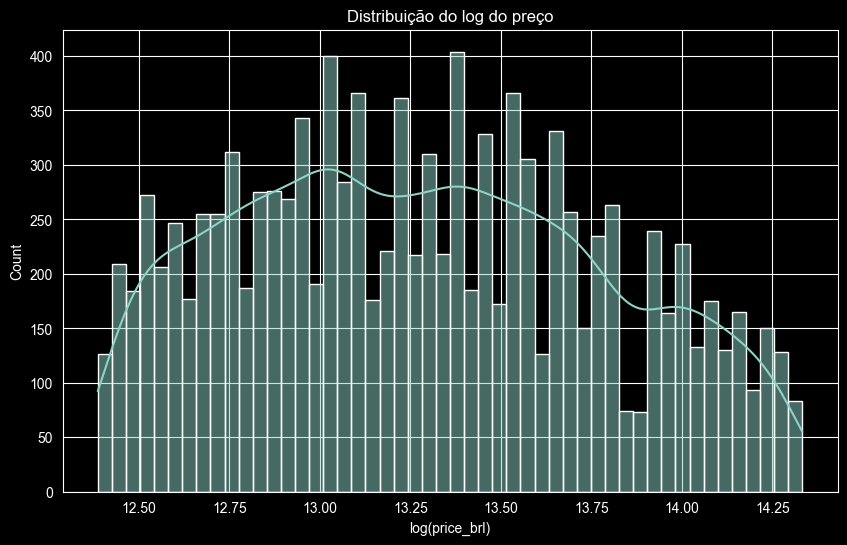

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))
sns.histplot(np.log(brasil_re_df_dropna['price_brl']), bins=50, kde=True)
plt.title('Distribuição do log do preço')
plt.xlabel('log(price_brl)')
plt.show()

* CORRELAÇÃO

A variável que mais influencia o preço é `area_m2`, com correlação moderada positiva. As variáveis de localização, como latitude e longitude, apresentam baixa correlação com o preço quando analisadas isoladamente, embora sejam fortemente correlacionadas entre si. As variáveis categóricas (tipo de imóvel, estado e região), após One-Hot Encoding, mostraram correlações fracas com o preço. De forma geral, o dataset apresenta baixa correlação linear com a variável alvo.

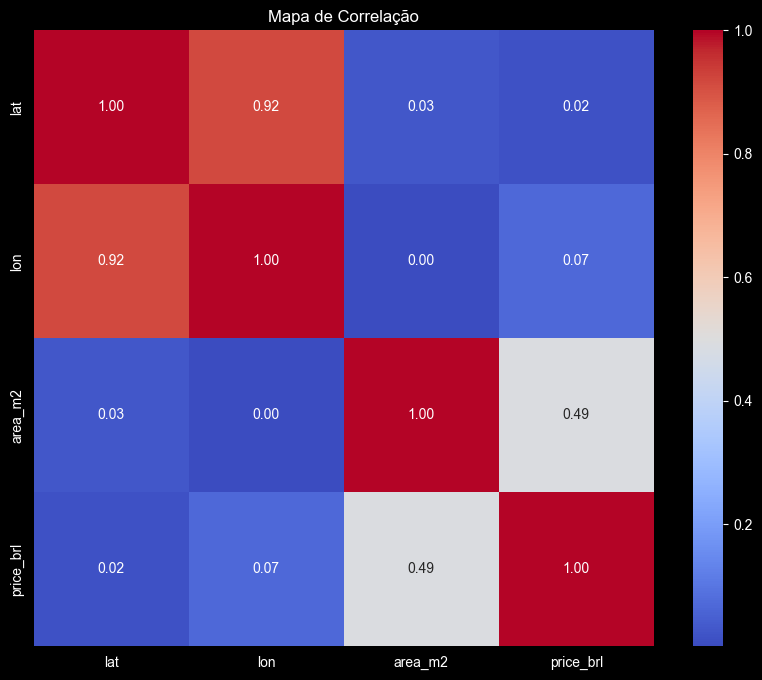

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = brasil_re_df_dropna.select_dtypes(include=['int64', 'float64'])

corr = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Mapa de Correlação')
plt.show()

C:\Users\1051392411001\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 146 (\x92) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\1051392411001\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 153 (\x99) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\1051392411001\AppData\Roaming\Python\Python314\site-packages\seaborn\utils.py:61: UserWarning: Glyph 139 (\x8b) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\1051392411001\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\1051392411001\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 153 (\x99) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\1051392411001\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabt

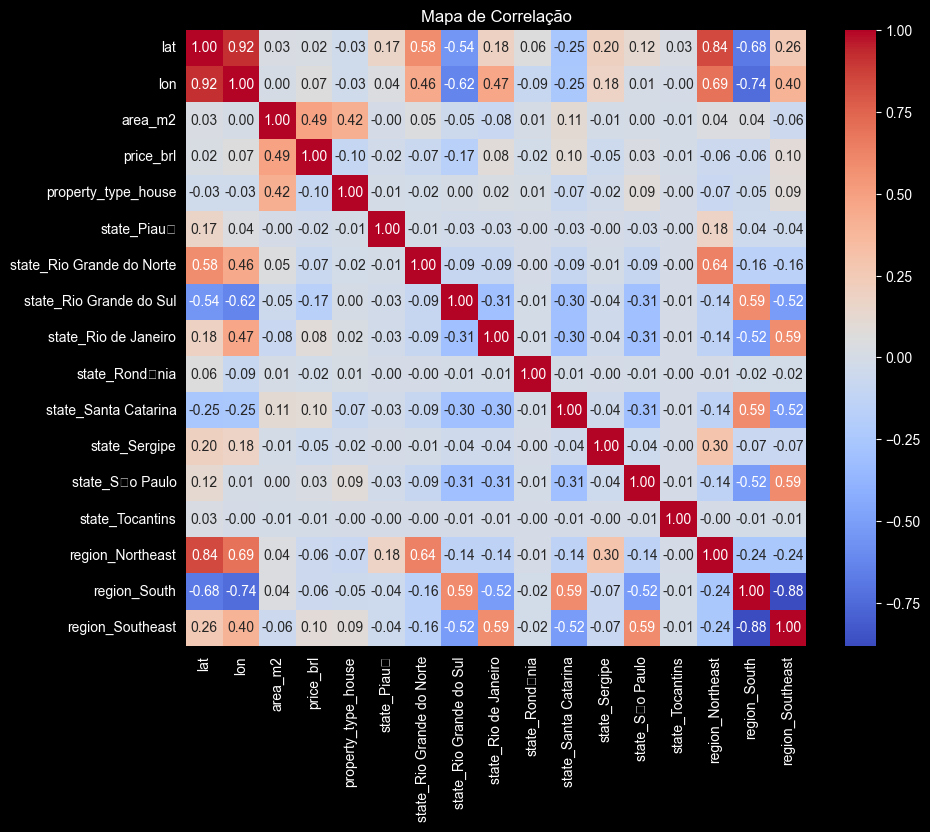

In [13]:
# após o One-Hot encoding

df_encoded = pd.get_dummies(brasil_re_df_dropna, columns=['property_type', 'state', 'region'], drop_first=True)
corr = df_encoded.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Mapa de Correlação')
plt.show()

* OUTLIERS

Os outliers foram identificados pela análise da distribuição do preço, onde valores muito altos se destacaram. A decisão foi manter esses valores, pois representam imóveis reais de alto padrão. Para reduzir seu impacto, foi aplicada a transformação logarítmica na variável alvo.

## Pré-processamento e Engenharia de Features
## Implementação dos seguintes Algoritmos Supervisionado
### Regressão Linear Múltipla
### Random Forest Regressor
### SVR (Support Vector Regression)
## Avaliação Comparativa (Métricas de Avaliação)
### Coeficiente de Determinação (R2)
### Erro Médio Absoluto (MAE)
### Erro Percentual Absoluto Médio (MAPE)
### RMSE (Root Mean Squared Error)
## Critérios para a "Escolha do Melhor Algoritmo"
### Resíduos: O gráfico de resíduos apresenta padrão? (Se sim, o modelo falhou em capturar alguma informação).
### Overfitting: A diferença entre o erro de treino e o de teste é muito grande?
### Interpretabilidade: O modelo precisa ser explicável ou apenas preciso?
## Visualização de Performance
## Discussão e Veredito Final
1. Qual modelo obteve a melhor performance global e por quê?
2. Houve sinais de overfitting (erro de treino muito menor que o de teste)?
3. Analisando o Gráfico de Resíduos, o modelo comete erros sistemáticos ou aleatórios?
4. Considerando o uso prático desse modelo em uma empresa, vocês recomendariam o modelo mais complexo (ex: RFR) ou o mais simples (Linear)? Justifiquem com base no equilíbrio entre precisão e interpretabilidade.
## Referências Bibliograficas